In [ ]:
import pandas as pd
from api.services.stats.stats import StatsService
from api.services.stats.emissions import EmissionsService
from api.services.stats.energy import EnergyService
from api.services.stats.behavior_change import BehaviorChangeService
import matplotlib.pyplot as plt
import numpy as np
# from api.models.query import EnergyExpenditure, EnergyByJourney, JourneyEnergyLeg
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [ ]:
def load_test_dataframe() -> pd.DataFrame:
    """Load the test CSV into a DataFrame."""
    df = pd.read_csv('./records_20260220_1640.csv')
    stats = StatsService()
    df = stats._preprocess_dataframe(df)
    return df

In [3]:
df = load_test_dataframe()

In [4]:
service = EmissionsService(df)

df_v1 = service._get_records_v1()
results_before_reco_v1 = service._compute_mode_emissions_v1(df_v1, apply_reco=False)
results_after_reco_v1 = service._compute_mode_emissions_v1(df_v1, apply_reco=True)

df_v2 = service._get_records_v2()
result_before_reco_v2 = service._compute_mode_emissions_v2(df_v2, apply_reco=False)
result_after_reco_v2 = service._compute_mode_emissions_v2(df_v2, apply_reco=True)


In [5]:
result_before_reco_v2

[Emissions(mode='bike', total=26, distances=14703.074767795977, journeys=1260, emissions=88.21844860677588),
 Emissions(mode='train', total=26, distances=25061.860961961276, journeys=990, emissions=200.49488769569024),
 Emissions(mode='car', total=26, distances=35668.29835262181, journeys=4500, emissions=6634.303493587658),
 Emissions(mode='pub', total=26, distances=6729.762250927576, journeys=1350, emissions=168.24405627318944),
 Emissions(mode='walking', total=26, distances=13525.399401309764, journeys=1260, emissions=0.0),
 Emissions(mode='moto', total=26, distances=47637.46101331974, journeys=2520, emissions=7383.80645706456),
 Emissions(mode='ebike', total=26, distances=5584.280846788244, journeys=990, emissions=61.42708931467068),
 Emissions(mode='other', total=26, distances=470.6540219363346, journeys=180, emissions=21.508888802490493)]

In [6]:
result_after_reco_v2 # 20'578 in total

[Emissions(mode='bike', total=26, distances=33071.172578233505, journeys=2250, emissions=198.42703546940106),
 Emissions(mode='cargo', total=26, distances=3675.417468769985, journeys=720, emissions=40.42959215646983),
 Emissions(mode='walking', total=26, distances=788.923572978966, journeys=450, emissions=0.0),
 Emissions(mode='train', total=26, distances=35769.54185612764, journeys=1080, emissions=286.15633484902105),
 Emissions(mode='ebike', total=26, distances=11587.268125145582, journeys=2520, emissions=127.45994937660137),
 Emissions(mode='elec', total=26, distances=2338.2326155343244, journeys=450, emissions=210.4409353980892),
 Emissions(mode='inter', total=26, distances=49446.15442669193, journeys=1710, emissions=2804.7792262242756),
 Emissions(mode='pub', total=26, distances=4134.665580241064, journeys=900, emissions=103.36663950602663)]

In [7]:
service.compute_modes_emission_reductions()

[EmissionReductions(mode='walking', total=26, reduced=146.74),
 EmissionReductions(mode='bike', total=26, reduced=1603.261),
 EmissionReductions(mode='ebike', total=26, reduced=1196.361),
 EmissionReductions(mode='pub', total=26, reduced=665.681),
 EmissionReductions(mode='train', total=26, reduced=2355.078)]

In [8]:
service.compute_modes_pro_emissions()

[Emissions(mode='pub', total=26, distances=522.767, journeys=18, emissions=13.069),
 Emissions(mode='moto', total=26, distances=19.708, journeys=2, emissions=3.055),
 Emissions(mode='car', total=26, distances=5343.701, journeys=54, emissions=993.928),
 Emissions(mode='train', total=26, distances=1086.41, journeys=4, emissions=8.691),
 Emissions(mode='plane', total=26, distances=2083339.331, journeys=338, emissions=547918.244)]

In [9]:
service = EnergyService(df)
df_v2 = service._get_records_v2()
# df_v2
service._compute_mode_energy_reco_v2(df_v2)

[EnergyExpenditure(mode='bike', total=26, total_time=8460.0, journeys=450, energy_kcal=78960.0, avg_daily_kcal=3036.923076923077),
 EnergyExpenditure(mode='cargo', total=26, total_time=2610.0, journeys=144, energy_kcal=20706.0, avg_daily_kcal=796.3846153846154),
 EnergyExpenditure(mode='walking', total=26, total_time=2700.0, journeys=90, energy_kcal=11025.0, avg_daily_kcal=424.03846153846155),
 EnergyExpenditure(mode='train', total=26, total_time=6390.0, journeys=216, energy_kcal=9691.5, avg_daily_kcal=372.75),
 EnergyExpenditure(mode='ebike', total=26, total_time=8370.0, journeys=504, energy_kcal=66402.0, avg_daily_kcal=2553.923076923077),
 EnergyExpenditure(mode='elec', total=26, total_time=900.0, journeys=90, energy_kcal=1365.0, avg_daily_kcal=52.5),
 EnergyExpenditure(mode='inter', total=26, total_time=10530.0, journeys=342, energy_kcal=33710.04, avg_daily_kcal=1296.54),
 EnergyExpenditure(mode='pub', total=26, total_time=4050.0, journeys=180, energy_kcal=6142.5, avg_daily_kcal=236

In [10]:
# service = EnergyService(df)
    
result = service.compute_modes_energy(apply_reco=True)
result

[EnergyExpenditure(mode='bike', total=92, total_time=8460.0, journeys=450, energy_kcal=78960.0, avg_daily_kcal=3036.92),
 EnergyExpenditure(mode='cargo', total=92, total_time=2610.0, journeys=144, energy_kcal=20706.0, avg_daily_kcal=796.38),
 EnergyExpenditure(mode='walking', total=92, total_time=2700.0, journeys=90, energy_kcal=11025.0, avg_daily_kcal=424.04),
 EnergyExpenditure(mode='train', total=92, total_time=6390.0, journeys=216, energy_kcal=9691.5, avg_daily_kcal=372.75),
 EnergyExpenditure(mode='ebike', total=92, total_time=8370.0, journeys=504, energy_kcal=66402.0, avg_daily_kcal=2553.92),
 EnergyExpenditure(mode='elec', total=92, total_time=900.0, journeys=90, energy_kcal=1365.0, avg_daily_kcal=52.5),
 EnergyExpenditure(mode='inter', total=92, total_time=10530.0, journeys=342, energy_kcal=33710.04, avg_daily_kcal=1296.54),
 EnergyExpenditure(mode='pub', total=92, total_time=4050.0, journeys=180, energy_kcal=6142.5, avg_daily_kcal=236.25)]

In [11]:
results = service.compute_journey_energy(apply_reco=False)

In [12]:
# Plot a barplot, stacked by token, of the energy expenditure per journey, extracted from service.compute_journey_energy(apply_reco=False)
results

EnergyByJourney(total=26, data=[JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='0', mode='bike', days=3, travel_time=0.8333333333333333, energy_kcal=419.9999999999999, is_intermodal=True), JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='0', mode='train', days=3, travel_time=3.333333333333333, energy_kcal=273.0, is_intermodal=True), JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='0', mode='bike', days=3, travel_time=0.8333333333333333, energy_kcal=419.9999999999999, is_intermodal=True), JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='1', mode='car', days=2, travel_time=5.0, energy_kcal=273.0, is_intermodal=False), JourneyEnergyLeg(token='r7xDnVDC2QafMyfvI_qQ_A', journey_id='0', mode='car', days=5, travel_time=20.0, energy_kcal=2730.0, is_intermodal=False), JourneyEnergyLeg(token='_ZZWZ5hMU9v_04s6Cm2H_g', journey_id='0', mode='bike', days=3, travel_time=40.0, energy_kcal=20160.0, is_intermodal=False), JourneyEnergyLeg(token='_ZZWZ5hMU9v

In [13]:
result

[EnergyExpenditure(mode='bike', total=92, total_time=8460.0, journeys=450, energy_kcal=78960.0, avg_daily_kcal=3036.92),
 EnergyExpenditure(mode='cargo', total=92, total_time=2610.0, journeys=144, energy_kcal=20706.0, avg_daily_kcal=796.38),
 EnergyExpenditure(mode='walking', total=92, total_time=2700.0, journeys=90, energy_kcal=11025.0, avg_daily_kcal=424.04),
 EnergyExpenditure(mode='train', total=92, total_time=6390.0, journeys=216, energy_kcal=9691.5, avg_daily_kcal=372.75),
 EnergyExpenditure(mode='ebike', total=92, total_time=8370.0, journeys=504, energy_kcal=66402.0, avg_daily_kcal=2553.92),
 EnergyExpenditure(mode='elec', total=92, total_time=900.0, journeys=90, energy_kcal=1365.0, avg_daily_kcal=52.5),
 EnergyExpenditure(mode='inter', total=92, total_time=10530.0, journeys=342, energy_kcal=33710.04, avg_daily_kcal=1296.54),
 EnergyExpenditure(mode='pub', total=92, total_time=4050.0, journeys=180, energy_kcal=6142.5, avg_daily_kcal=236.25)]

## Energy Expenditure Visualizations - Per Person View

In [14]:
# Mode colors (matching viz_v2.ipynb)
color_mod = {
    'car': '#7030A0',
    'carpool': '#4f4f4f',
    'bike': '#35a040',
    'ebike': '#357165',
    'walking': '#c7ff0a',
    'train': '#cfd6b9',
    'pub': '#80a795',
    'moto': '#D86ECC',
    'inter': '#caad2e'
}

mode_labels = {
    'car': 'Car',
    'carpool': 'Carpool',
    'bike': 'Bike',
    'ebike': 'E-bike',
    'walking': 'Walking',
    'train': 'Train',
    'pub': 'Public Transport',
    'moto': 'Motorcycle',
    'inter': 'Intermodal'
}

In [15]:
def prepare_energy_plot_data(journey_energy_result):
    """
    Transform EnergyByJourney result into plot-ready DataFrame.
    
    Calculates energy per journey execution (energy_kcal / days) and
    organizes by token and mode for stacked plotting.
    
    Returns:
        DataFrame with tokens as index, modes as columns, sorted by total energy
    """
    import pandas as pd
    
    # Convert journey legs to records
    records = []
    for leg in journey_energy_result.data:
        energy_per_journey = leg.energy_kcal / (leg.days * 2 / 5 * 45) if leg.days > 0 else 0
        records.append({
            'token': leg.token,
            'mode': leg.mode,
            'energy_per_journey': energy_per_journey
        })
    
    if not records:
        return pd.DataFrame()
    
    df = pd.DataFrame(records)
    
    # Group by token and mode, sum energy per journey
    df_grouped = df.groupby(['token', 'mode'])['energy_per_journey'].sum().unstack(fill_value=0)
    
    # Calculate total energy per token for sorting
    df_grouped['_total'] = df_grouped.sum(axis=1)
    df_grouped = df_grouped.sort_values('_total', ascending=False)
    
    # Remove the total column
    total_col = df_grouped['_total']
    df_grouped = df_grouped.drop('_total', axis=1)
    
    return df_grouped, total_col

### Current Mode Energy Expenditure

In [16]:
# Get current mode journey energy data
journey_energy_current = service.compute_journey_energy(apply_reco=False)
df_current, total_current = prepare_energy_plot_data(journey_energy_current)

In [17]:
journey_energy_current

EnergyByJourney(total=26, data=[JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='0', mode='bike', days=3, travel_time=0.8333333333333333, energy_kcal=419.9999999999999, is_intermodal=True), JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='0', mode='train', days=3, travel_time=3.333333333333333, energy_kcal=273.0, is_intermodal=True), JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='0', mode='bike', days=3, travel_time=0.8333333333333333, energy_kcal=419.9999999999999, is_intermodal=True), JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='1', mode='car', days=2, travel_time=5.0, energy_kcal=273.0, is_intermodal=False), JourneyEnergyLeg(token='r7xDnVDC2QafMyfvI_qQ_A', journey_id='0', mode='car', days=5, travel_time=20.0, energy_kcal=2730.0, is_intermodal=False), JourneyEnergyLeg(token='_ZZWZ5hMU9v_04s6Cm2H_g', journey_id='0', mode='bike', days=3, travel_time=40.0, energy_kcal=20160.0, is_intermodal=False), JourneyEnergyLeg(token='_ZZWZ5hMU9v

In [18]:
# bike-train-bike with 5 minutes total time comes out at 0.5 - 4 - 0.5 minutes.
# 0.5 minutes of biking at 8 METs somehow results in 252 kcal
# The calculation is 
# 0.5 minutes / 60 minutes * 45 weeks * 2 trips * 3 days / 5 days * 8 METs * 70 kg (average weight) = 252 kcal
# This corresponds to total expenditure for that journey over the 45 weeks
# The journey calculation would be 0.5 / 60 * 8 * 70



In [19]:
# travel time for EtyqBJGs25pvr-DRg5kwbw
journey_df = service._build_journey_attributes(df_v2)
journey_df[journey_df['token'] == 't1vihPF3neWfB690zUQflg']
# journey_df["travel_time"] # this is in minutes
# 20160 kcal over the whole year
# A single trip would correspon to 373
# 40 minutes in public transport corresponds to 60 kcal per trip
# In total, we should therefore reach 
# journey_df[journey_df["is_walking_intermodal"]]

,token,journey,days,dist,travel_time,mode,is_train,is_walking,has_train,n_modes,is_intermodal,is_walking_intermodal
23,t1vihPF3neWfB690zUQflg,0,3.0,29.684074,50,car,False,False,False,2,False,True
24,t1vihPF3neWfB690zUQflg,0,3.0,29.684074,50,walking,False,True,False,2,False,True
25,t1vihPF3neWfB690zUQflg,1,1.0,29.684074,50,walking,False,True,False,1,False,False


In [20]:
# t1vihPF3neWfB690zUQflg is walking + car, but this is not recognized as intermodality

In [21]:
df_current.sort_values(by = "walking", ascending=False)

mode,bike,car,ebike,moto,other,pub,train,walking
token,,,,,,,,
t1vihPF3neWfB690zUQflg,0.000000,37.916667,0.000000,0.000000,0.000000,0.000000,0.000000,245.000000
-71D6AOgBoLpJD-ywITzuA,0.000000,0.000000,0.000000,65.333333,10.888889,0.000000,20.222222,40.833333
0staGXI60pjIacBOe5RidA,0.000000,0.000000,0.000000,0.000000,0.000000,13.902778,55.611111,40.833333
az96jfBmi4YeEGGFgxaWiA,0.000000,0.000000,0.000000,98.000000,0.000000,7.583333,30.333333,40.833333
EHyxNX2RklcBEoewGZF9lA,23.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.416667
_ZZWZ5hMU9v_04s6Cm2H_g,373.333333,0.000000,0.000000,0.000000,0.000000,60.666667,0.000000,0.000000
HPXwH-F06Bnwweavplz8bg,0.000000,45.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5Bx-sYRw1l2xI24kqPXgXA,0.000000,15.166667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
d4CI_1kHZK5FlCl9MzdHjQ,0.000000,7.583333,0.000000,16.333333,0.000000,0.000000,0.000000,0.000000


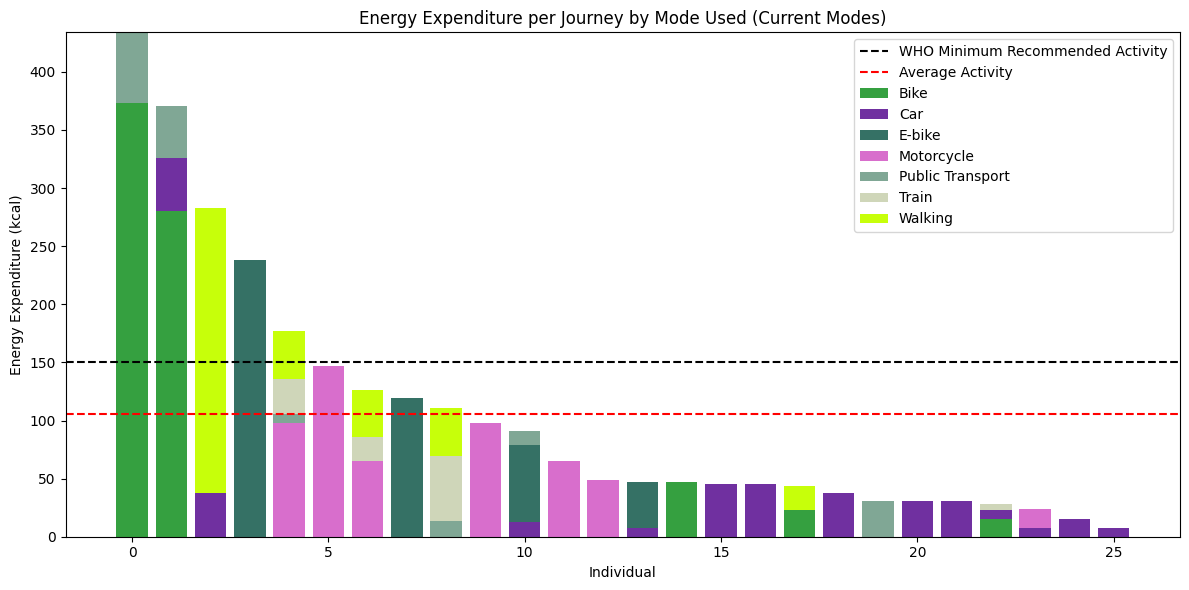

In [22]:
# Plot stacked bar chart for current modes
plt.figure(figsize=(12, 6))

# Create bottom tracker for stacking
bottom = pd.Series([0] * len(df_current), index=df_current.index)

# Plot each mode as a stacked segment
for mode in df_current.columns:
    if mode in color_mod:
        values = df_current[mode]
        plt.bar(
            range(len(values)),
            values,
            bottom=bottom,
            color=color_mod[mode],
            label=mode_labels.get(mode, mode)
        )
        bottom += values

# Add reference lines
plt.axhline(y=150, color='k', linestyle='--', label='WHO Minimum Recommended Activity')
plt.axhline(y=total_current.mean(), color='r', linestyle='--', label='Average Activity')

# Labels and styling
plt.xlabel('Individual')
plt.ylabel('Energy Expenditure (kcal)')
plt.title('Energy Expenditure per Journey by Mode Used (Current Modes)')
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig('describe_energy_current.png', dpi=200, transparent=True)
plt.show()

### Recommended Mode Energy Expenditure

In [23]:
# Get recommended mode journey energy data
journey_energy_reco = service.compute_journey_energy(apply_reco=True)
df_reco, total_reco = prepare_energy_plot_data(journey_energy_reco)

In [24]:
df_reco

mode,bike,cargo,ebike,elec,inter,pub,train,walking
token,,,,,,,,
_ZZWZ5hMU9v_04s6Cm2H_g,373.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
QOsRAVjrm91cqy0Z6nbT5g,0.000000,0.000000,357.000000,0.000000,0.000000,0.000000,0.000000,0.0
_F4m6rGcmjDlqp0EAEsIKA,280.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
UY8fTPsH0-Mnuxb8oMoZKg,0.000000,0.000000,238.000000,0.000000,0.000000,0.000000,0.000000,0.0
869vsX_A0QLuNEfx9O-plA,186.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
t1vihPF3neWfB690zUQflg,0.000000,0.000000,0.000000,0.000000,160.066667,0.000000,0.000000,0.0
r7xDnVDC2QafMyfvI_qQ_A,0.000000,158.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
e3P4NtXOEZ42li8HTR4s_g,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,122.5
aPhHpooh5OgzAshs1R4vjw,0.000000,119.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


In [25]:
journey_energy_reco

EnergyByJourney(total=26, data=[JourneyEnergyLeg(token='EtyqBJGs25pvr-DRg5kwbw', journey_id='reco', mode='bike', days=5, travel_time=5.0, energy_kcal=4200.0, is_intermodal=False), JourneyEnergyLeg(token='r7xDnVDC2QafMyfvI_qQ_A', journey_id='reco', mode='cargo', days=5, travel_time=20.0, energy_kcal=14280.0, is_intermodal=False), JourneyEnergyLeg(token='_ZZWZ5hMU9v_04s6Cm2H_g', journey_id='reco', mode='bike', days=5, travel_time=40.0, energy_kcal=33600.0, is_intermodal=False), JourneyEnergyLeg(token='e3P4NtXOEZ42li8HTR4s_g', journey_id='reco', mode='walking', days=5, travel_time=30.0, energy_kcal=11025.0, is_intermodal=False), JourneyEnergyLeg(token='869vsX_A0QLuNEfx9O-plA', journey_id='reco', mode='bike', days=3, travel_time=20.0, energy_kcal=10080.0, is_intermodal=False), JourneyEnergyLeg(token='--IVKjvBiM56rrgeR21WMw', journey_id='reco', mode='bike', days=2, travel_time=5.0, energy_kcal=1680.0, is_intermodal=False), JourneyEnergyLeg(token='0staGXI60pjIacBOe5RidA', journey_id='reco', 

In [ ]:
total_reco

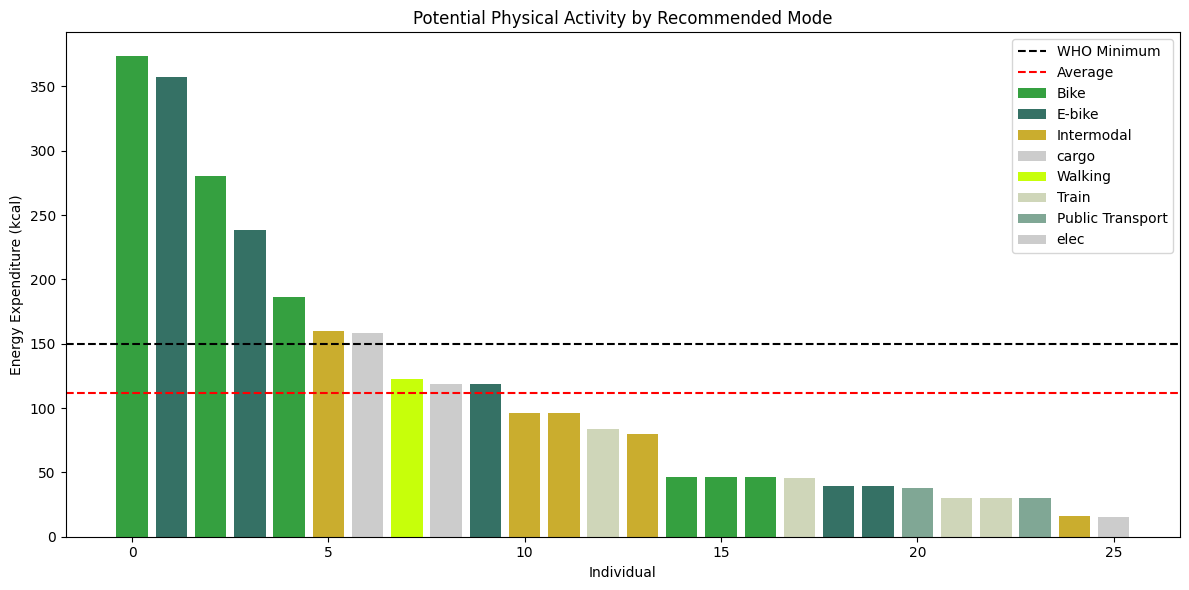

In [26]:
# Plot bar chart for recommended modes (single bar per person)
# Each person gets one bar colored by their dominant recommended mode

plt.figure(figsize=(12, 6))

# For each token, find the dominant mode (mode with highest energy)
dominant_modes = df_reco.idxmax(axis=1)
colors = [color_mod.get(mode, '#cccccc') for mode in dominant_modes]

# Plot bars
bars = plt.bar(range(len(total_reco)), total_reco.values, color=colors)

# Add reference lines
plt.axhline(y=150, color='k', linestyle='--', label='WHO Minimum Recommended Activity')
plt.axhline(y=total_reco.mean(), color='r', linestyle='--', label='Average Activity')

# Create legend with mode colors
unique_modes = dominant_modes.unique()
legend_elements = [
    Patch(facecolor=color_mod.get(mode, '#cccccc'), label=mode_labels.get(mode, mode))
    for mode in unique_modes
]
legend_elements.insert(0, Line2D([0], [0], color='k', linestyle='--', label='WHO Minimum'))
legend_elements.insert(1, Line2D([0], [0], color='r', linestyle='--', label='Average'))

# Labels and styling
plt.xlabel('Individual')
plt.ylabel('Energy Expenditure (kcal)')
plt.title('Potential Physical Activity by Recommended Mode')
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()

# Save figure
plt.savefig('describe_energy_reco.png', dpi=200, transparent=True)
plt.show()

In [27]:
df = load_test_dataframe()
service = EnergyService(df)

# Create sample without train
sample_df = pd.DataFrame([
    {'token': 'test1', 'journey': '0', 'mode': 'walking', 'is_intermodal': True, 'is_walking': True, 
      'has_train': False, 'n_modes': 3, 'n_walking': 1, 'travel_time': 60.0, 'days': 5},
    {'token': 'test1', 'journey': '0', 'mode': 'bike', 'is_intermodal': True, 'is_walking': False, 
      'has_train': False, 'n_modes': 3, 'n_walking': 1, 'travel_time': 60.0, 'days': 5},
    {'token': 'test1', 'journey': '0', 'mode': 'car', 'is_intermodal': True, 'is_walking': False, 
      'has_train': False, 'n_modes': 3, 'n_walking': 1, 'travel_time': 60.0, 'days': 5}
])

result_df = service._calculate_intermodal_time_fractions(sample_df)
    

In [28]:
result_df

,token,journey,mode,is_intermodal,is_walking,has_train,n_modes,n_walking,travel_time,days,time_fraction
0,test1,0,walking,True,True,False,3,1,60.0,5,0.166667
1,test1,0,bike,True,False,False,3,1,60.0,5,0.416667
2,test1,0,car,True,False,False,3,1,60.0,5,0.416667


In [29]:
df = load_test_dataframe()
service = EnergyService(df)

# Create sample with very short time
sample_df = pd.DataFrame([
    {'token': 'test1', 'journey': '0', 'mode': 'walking', 'is_intermodal': True, 'is_walking': True, 
      'has_train': False, 'n_modes': 2, 'n_walking': 1, 'travel_time': 7.0, 'days': 5},
    {'token': 'test1', 'journey': '0', 'mode': 'bike', 'is_intermodal': True, 'is_walking': False, 
      'has_train': False, 'n_modes': 2, 'n_walking': 1, 'travel_time': 7.0, 'days': 5}
])

result_df = service._calculate_intermodal_time_fractions(sample_df)
result_df

,token,journey,mode,is_intermodal,is_walking,has_train,n_modes,n_walking,travel_time,days,time_fraction
0,test1,0,walking,True,True,False,2,1,7.0,5,1.0
1,test1,0,bike,True,False,False,2,1,7.0,5,0.0


In [30]:
df = load_test_dataframe()
service = BehaviorChangeService(df)

In [31]:
service.compute_behavior_change_stats()

BehaviorChangeStats(total_lever_responses=14, total_motivation_responses=13, lever_aggregation_type='all_aggregated', motivation_aggregation_type='all_aggregated', by_mode_levers=[BehaviorChangeByMode(mode='Tous modes', response_count=14, levers=[BehaviorChangeLever(category='finance', label='Aide financière', count=5, percentage=26.32), BehaviorChangeLever(category='flexibility', label='Flexibilité', count=5, percentage=26.32), BehaviorChangeLever(category='collective', label='Changement collectif', count=2, percentage=10.53), BehaviorChangeLever(category='environment', label='Aménagement environnement', count=6, percentage=31.58), BehaviorChangeLever(category='other', label='Autre', count=1, percentage=5.26)], motivation=[])], by_mode_motivation=[BehaviorChangeByMode(mode='Tous modes', response_count=13, levers=[], motivation=[BehaviorChangeMotivation(level=5, label='Très motivé·e', count=8, percentage=61.54), BehaviorChangeMotivation(level=4, label='Plutôt motivé·e', count=2, percen

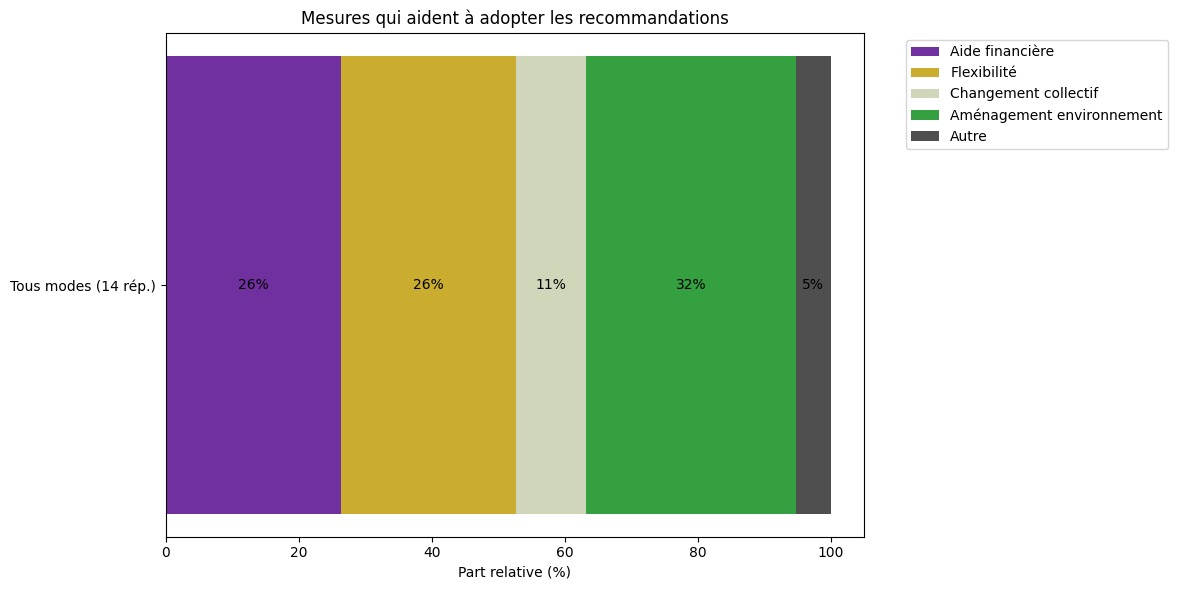

In [32]:
# BEHAVIOR CHANGE - LEVERS


# Get behavior change stats from API
behavior_change = service.compute_behavior_change_stats()

if behavior_change and len(behavior_change.by_mode_levers) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data
    modes = [m.mode for m in behavior_change.by_mode_levers if m.mode != "Total"]
    categories = ["finance", "flexibility", "collective", "environment", "other"]
    cat_labels = {
        "finance": "Aide financière",
        "flexibility": "Flexibilité",
        "collective": "Changement collectif",
        "environment": "Aménagement environnement",
        "other": "Autre"
    }
    colors = {
        "finance": "#7030A0",
        "flexibility": "#caad2e",
        "collective": "#cfd6b9",
        "environment": "#35a040",
        "other": "#4f4f4f"
    }
    
    # Create stacked horizontal bar chart
    bottom = np.zeros(len(modes))
    for category in categories:
        values = []
        for mode_stats in behavior_change.by_mode_levers:
            if mode_stats.mode != "Total":
                lever = next((l for l in mode_stats.levers if l.category == category), None)
                values.append(lever.percentage if lever else 0)
        
        ax.barh(modes, values, left=bottom, label=cat_labels[category], color=colors[category])
        
        # Add percentage labels
        for i, (mode, value) in enumerate(zip(modes, values)):
            if value > 0:
                ax.text(bottom[i] + value/2, i, f"{int(round(value))}%", 
                       va="center", ha="center", color="black", fontsize=10)
        
        bottom += values
    
    # Add response counts to y-axis labels
    mode_labels = []
    for mode_stats in behavior_change.by_mode_levers:
        if mode_stats.mode != "Total":
            mode_labels.append(f"{mode_stats.mode} ({mode_stats.response_count} rép.)")
    ax.set_yticks(range(len(modes)))
    ax.set_yticklabels(mode_labels)
    
    ax.set_xlabel("Part relative (%)")
    ax.set_title("Mesures qui aident à adopter les recommandations")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.show()
else:
    print("No behavior change lever data available")


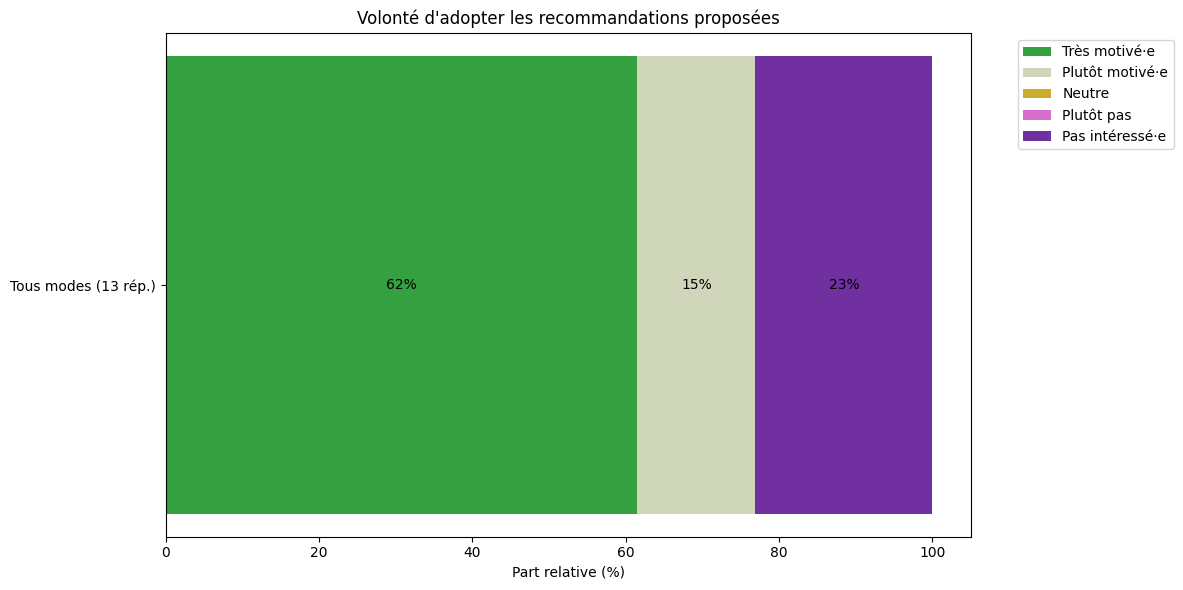

In [33]:
# BEHAVIOR CHANGE - MOTIVATION
import matplotlib.pyplot as plt
import numpy as np

behavior_change = service.compute_behavior_change_stats()

if behavior_change and len(behavior_change.by_mode_motivation) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Prepare data
    modes = [m.mode for m in behavior_change.by_mode_motivation if m.mode != "Total"]
    notes = [5, 4, 3, 2, 1]  # Order is important
    notes_labels = {
        1: "Pas intéressé·e",
        2: "Plutôt pas",
        3: "Neutre",
        4: "Plutôt motivé·e",
        5: "Très motivé·e"
    }
    colors = {
        1: "#7030A0",
        2: "#D86ECC",
        3: "#caad2e",
        4: "#cfd6b9",
        5: "#35a040"
    }
    
    # Create stacked horizontal bar chart
    bottom = np.zeros(len(modes))
    for note in notes:
        values = []
        for mode_stats in behavior_change.by_mode_motivation:
            if mode_stats.mode != "Total":
                motiv = next((m for m in mode_stats.motivation if m.level == note), None)
                values.append(motiv.percentage if motiv else 0)
        
        ax.barh(modes, values, left=bottom, label=notes_labels[note], color=colors[note])
        
        # Add percentage labels
        for i, (mode, value) in enumerate(zip(modes, values)):
            if value > 0:
                ax.text(bottom[i] + value/2, i, f"{int(round(value))}%",
                       va="center", ha="center", color="black", fontsize=10)
        
        bottom += values
    
    # Add response counts to y-axis labels
    mode_labels = []
    for mode_stats in behavior_change.by_mode_motivation:
        if mode_stats.mode != "Total":
            mode_labels.append(f"{mode_stats.mode} ({mode_stats.response_count} rép.)")
    ax.set_yticks(range(len(modes)))
    ax.set_yticklabels(mode_labels)
    
    ax.set_xlabel("Part relative (%)")
    ax.set_title("Volonté d'adopter les recommandations proposées")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.show()
else:
    print("No behavior change motivation data available")


## Professional Travel Emission Reductions

This visualization shows CO2 emission savings when professional travel recommendations are applied.

In [34]:
# Get professional travel emission reductions
service = EmissionsService(df)
pro_emission_reductions = service.compute_modes_pro_emission_reductions()

In [35]:
pro_emission_reductions

[EmissionReductions(mode='elec', total=26, reduced=153.806),
 EmissionReductions(mode='bike', total=26, reduced=2.877),
 EmissionReductions(mode='avoid', total=26, reduced=545842.748),
 EmissionReductions(mode='train', total=26, reduced=2724.249),
 EmissionReductions(mode='elec_moto', total=26, reduced=1.439)]

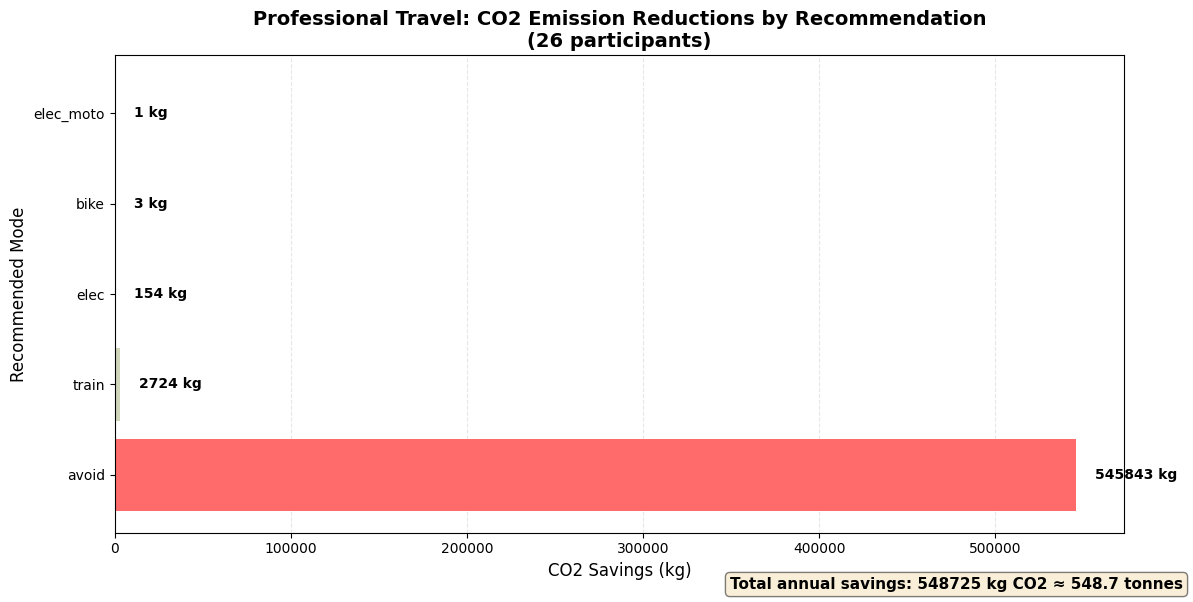

In [36]:
# PROFESSIONAL TRAVEL - EMISSION REDUCTIONS
import matplotlib.pyplot as plt
import numpy as np

if pro_emission_reductions and len(pro_emission_reductions) > 0:
    # Sort by reduced emissions (highest first)
    sorted_reductions = sorted(pro_emission_reductions, key=lambda x: x.reduced, reverse=True)
    
    # Prepare data
    modes = [r.mode for r in sorted_reductions]
    savings_kg = [r.reduced for r in sorted_reductions]
    total_records = sorted_reductions[0].total if sorted_reductions else 0
    
    # Mode colors (matching previous visualizations)
    mode_colors = {
        'car': '#7030A0',
        'carpool': '#4f4f4f',
        'bike': '#35a040',
        'ebike': '#357165',
        'walking': '#c7ff0a',
        'train': '#cfd6b9',
        'pub': '#80a795',
        'moto': '#D86ECC',
        'avoid': '#ff6b6b',  # Red for avoiding travel
        'plane': '#caad2e',
    }
    
    colors = [mode_colors.get(mode, '#808080') for mode in modes]
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(modes, savings_kg, color=colors)
    
    # Add value labels on bars
    for i, (mode, savings) in enumerate(zip(modes, savings_kg)):
        ax.text(savings + max(savings_kg)*0.02, i, f"{int(round(savings))} kg",
               va='center', ha='left', fontsize=10, fontweight='bold')
    
    # Formatting
    ax.set_xlabel('CO2 Savings (kg)', fontsize=12)
    ax.set_ylabel('Recommended Mode', fontsize=12)
    ax.set_title(f'Professional Travel: CO2 Emission Reductions by Recommendation\n({total_records} participants)', 
                fontsize=14, fontweight='bold')
    
    # Add grid for readability
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add total savings annotation
    total_savings = sum(savings_kg)
    fig.text(0.99, 0.01, f'Total annual savings: {int(round(total_savings))} kg CO2 ≈ {total_savings/1000:.1f} tonnes',
            ha='right', fontsize=11, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("No professional travel emission reduction data available")

### Professional vs Commute Emission Reductions Comparison

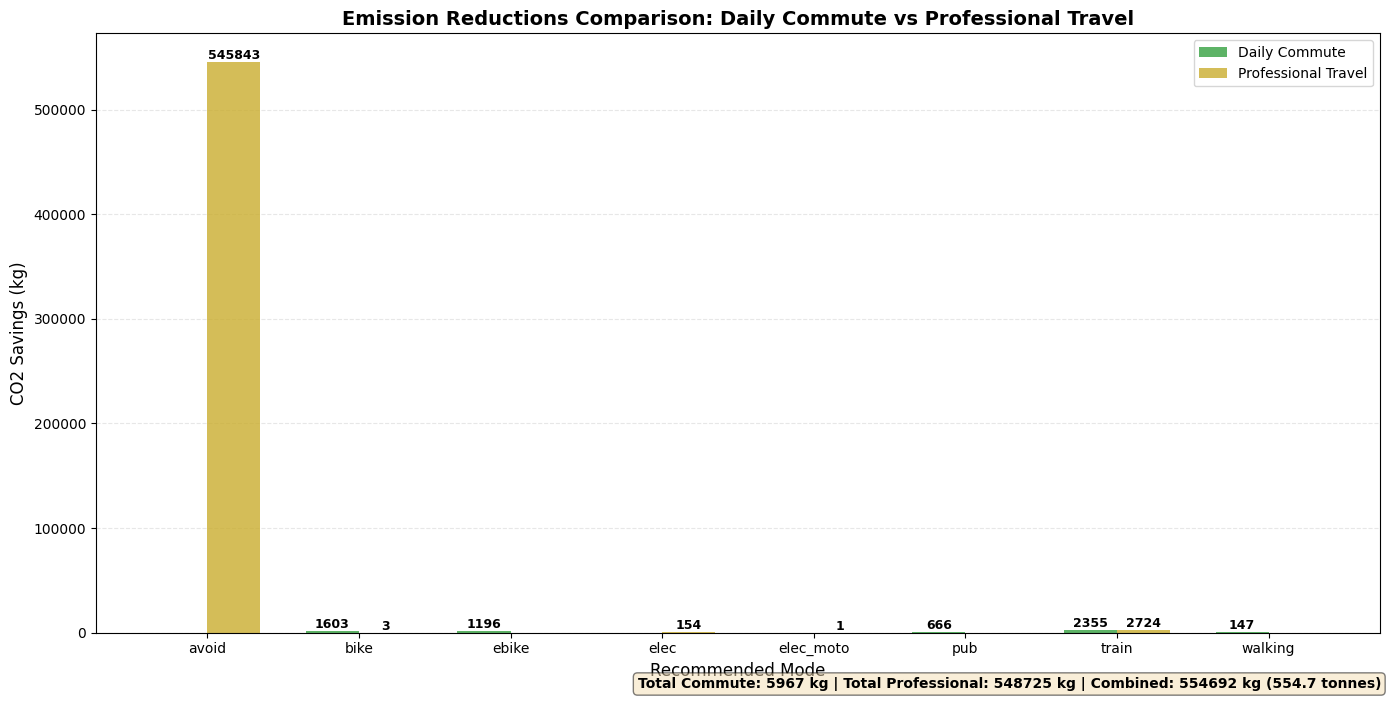

In [37]:
# COMPARISON: Professional vs Commute Emission Reductions
import matplotlib.pyplot as plt
import numpy as np

# Get both types of reductions
commute_reductions = service.compute_modes_emission_reductions()
pro_reductions = service.compute_modes_pro_emission_reductions()

if commute_reductions and pro_reductions:
    # Get all unique modes
    all_modes = set([r.mode for r in commute_reductions] + [r.mode for r in pro_reductions])
    all_modes = sorted(list(all_modes))
    
    # Build data arrays
    commute_savings = []
    pro_savings = []
    
    for mode in all_modes:
        commute = next((r.reduced for r in commute_reductions if r.mode == mode), 0)
        pro = next((r.reduced for r in pro_reductions if r.mode == mode), 0)
        commute_savings.append(commute)
        pro_savings.append(pro)
    
    # Create grouped bar chart
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(len(all_modes))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, commute_savings, width, label='Daily Commute', color='#35a040', alpha=0.8)
    bars2 = ax.bar(x + width/2, pro_savings, width, label='Professional Travel', color='#caad2e', alpha=0.8)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(round(height))}',
                       ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Recommended Mode', fontsize=12)
    ax.set_ylabel('CO2 Savings (kg)', fontsize=12)
    ax.set_title('Emission Reductions Comparison: Daily Commute vs Professional Travel',
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(all_modes)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add totals
    total_commute = sum(commute_savings)
    total_pro = sum(pro_savings)
    fig.text(0.99, 0.01, 
            f'Total Commute: {int(round(total_commute))} kg | Total Professional: {int(round(total_pro))} kg | '
            f'Combined: {int(round(total_commute + total_pro))} kg ({(total_commute + total_pro)/1000:.1f} tonnes)',
            ha='right', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("Comparison not available - missing data")